# Bank Marketing Data Analysis
This notebook presents an analysis of the `bankmarketing.csv` dataset, which includes data related to a bank's marketing campaigns. The main goal is to understand customer behavior and predict whether a client will subscribe to a term deposit.

In [28]:

import pandas as pd

# Load the dataset
df = pd.read_csv("C:\\Users\\vr204\\OneDrive\\Desktop\\bankmarketing.csv")

# Display the first few rows
df.head()


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


In [29]:

# Check for missing values and data types
df.isnull().sum()



age               0
job               0
marital           0
education         0
default           0
housing           0
loan              0
contact           0
month             0
day_of_week       0
duration          0
campaign          0
pdays             0
previous          0
poutcome          0
emp.var.rate      0
cons.price.idx    0
cons.conf.idx     0
euribor3m         0
nr.employed       0
y                 0
dtype: int64

In [30]:
df.drop(df[df['duration'] == 0].index, inplace=True)

In [31]:
# Check the total number of rows
print("Current row count:", len(df))

Current row count: 41184


In [32]:

# Summary statistics
# 1. Summary statistics for Numerical features (Age, Duration, etc.)
print("--- Numerical Data ---")
print(df.describe())

# 2. Summary statistics for Categorical features (Job, Education, etc.)
print("\n--- Categorical Data ---")
print(df.describe(include=['object']))


--- Numerical Data ---
                age      duration      campaign         pdays      previous  \
count  41184.000000  41184.000000  41184.000000  41184.000000  41184.000000   
mean      40.023529    258.310096      2.567381    962.471907      0.172980   
std       10.421044    259.279344      2.769895    186.919638      0.494922   
min       17.000000      1.000000      1.000000      0.000000      0.000000   
25%       32.000000    102.000000      1.000000    999.000000      0.000000   
50%       38.000000    180.000000      2.000000    999.000000      0.000000   
75%       47.000000    319.000000      3.000000    999.000000      0.000000   
max       98.000000   4918.000000     56.000000    999.000000      7.000000   

       emp.var.rate  cons.price.idx  cons.conf.idx     euribor3m   nr.employed  
count   41184.00000    41184.000000   41184.000000  41184.000000  41184.000000  
mean        0.08192       93.575686     -40.502508      3.621337   5167.037145  
std         1.57096   

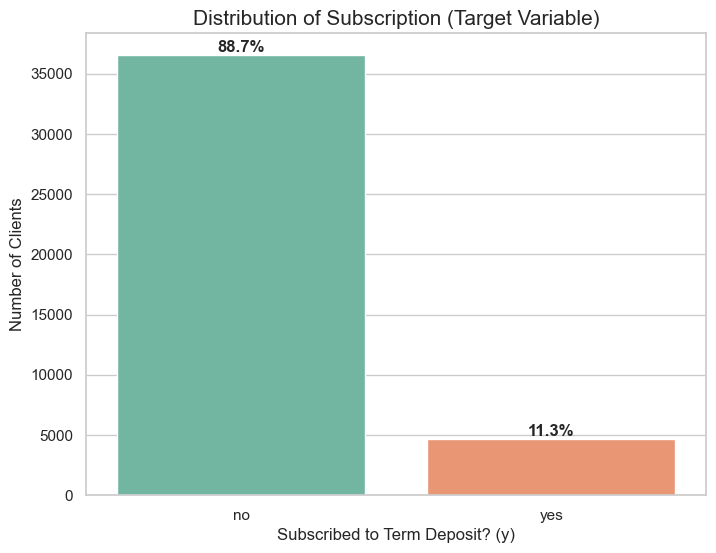

In [33]:

import seaborn as sns
import matplotlib.pyplot as plt

# Plot the distribution of the target variable

# Setting the visual style
sns.set_theme(style="whitegrid")
plt.figure(figsize=(8, 6))

# Creating the countplot
ax = sns.countplot(x='y', data=df, hue='y', palette='Set2', legend=False)

# Adding labels and title
plt.title('Distribution of Subscription (Target Variable)', fontsize=15)
plt.xlabel('Subscribed to Term Deposit? (y)', fontsize=12)
plt.ylabel('Number of Clients', fontsize=12)

# Adding percentage annotations on top of the bars
total = len(df)
for p in ax.patches:
    percentage = f'{100 * p.get_height() / total:.1f}%'
    x = p.get_x() + p.get_width() / 2
    y = p.get_height()
    ax.annotate(percentage, (x, y), ha='center', va='bottom', fontsize=12, fontweight='bold')

plt.show()

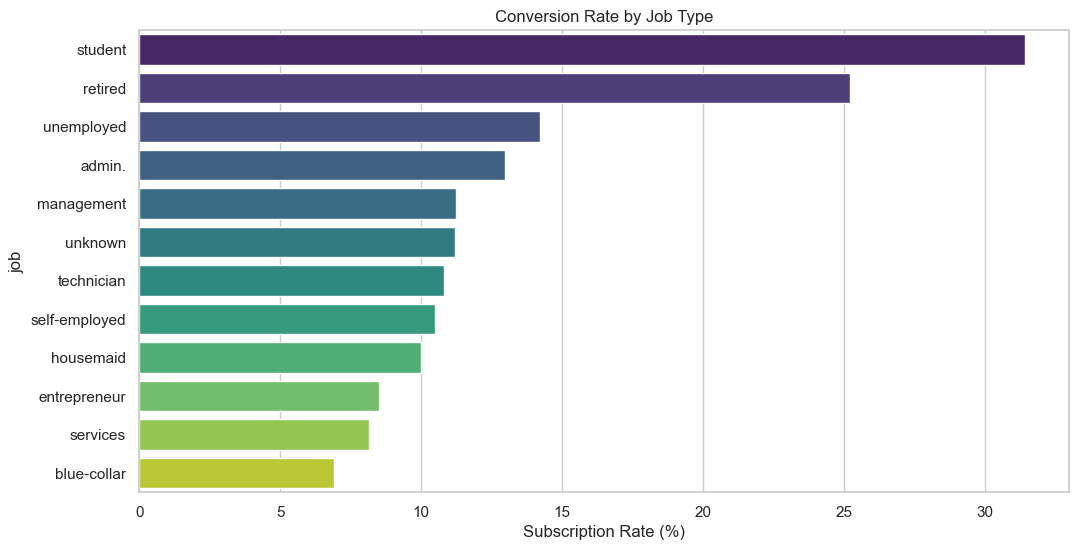

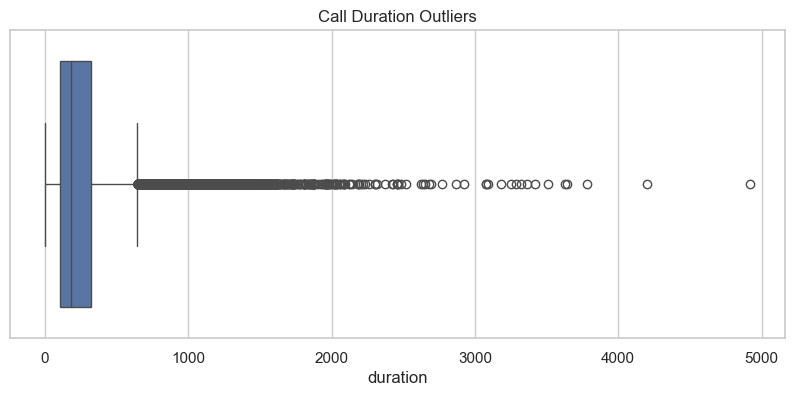

In [34]:
# Conversion Rate by Job
plt.figure(figsize=(12, 6))
job_conv = df.groupby('job')['y'].value_counts(normalize=True).unstack()['yes'].sort_values(ascending=False)

sns.barplot(
    x=job_conv.values * 100, 
    y=job_conv.index, 
    hue=job_conv.index, 
    palette='viridis', 
    legend=False
) # The parenthesis belongs here!

plt.title('Conversion Rate by Job Type')
plt.xlabel('Subscription Rate (%)')
plt.show()

# Call Duration Outliers
plt.figure(figsize=(10, 4))
sns.boxplot(x='duration', data=df)
plt.title('Call Duration Outliers')
plt.show()

C:\Users\vr204\AppData\Local\Temp\ipykernel_5920\1774820805.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  eco_trend = df.groupby('euribor_bins')['y'].value_counts(normalize=True).unstack()['yes']


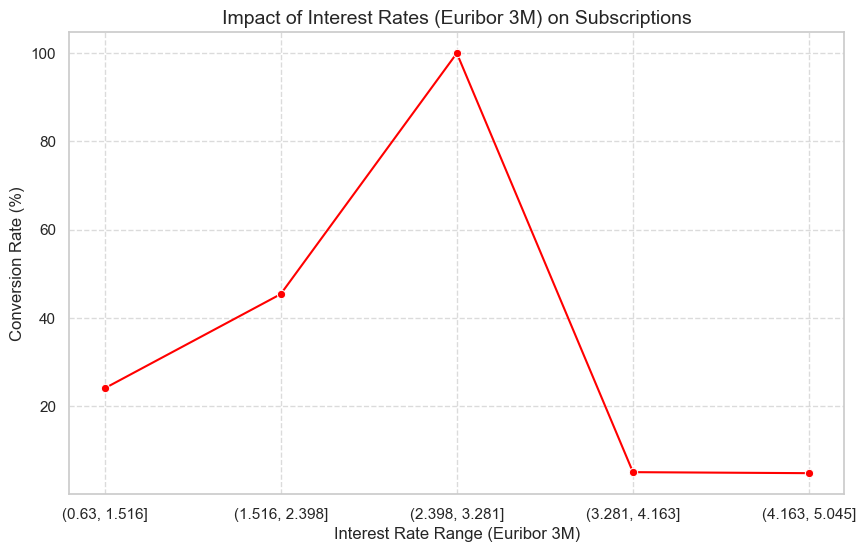

In [35]:
# 1. Create 5 equal-sized bins for the interest rate
df['euribor_bins'] = pd.cut(df['euribor3m'], bins=5)

# 2. Calculate the percentage of 'yes' responses for each bin
eco_trend = df.groupby('euribor_bins')['y'].value_counts(normalize=True).unstack()['yes']

# 3. Create the line plot
plt.figure(figsize=(10, 6))
sns.lineplot(
    x=[str(interval) for interval in eco_trend.index], 
    y=eco_trend.values * 100, 
    marker='o', 
    color='red'
)

plt.title('Impact of Interest Rates (Euribor 3M) on Subscriptions', fontsize=14)
plt.xlabel('Interest Rate Range (Euribor 3M)')
plt.ylabel('Conversion Rate (%)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

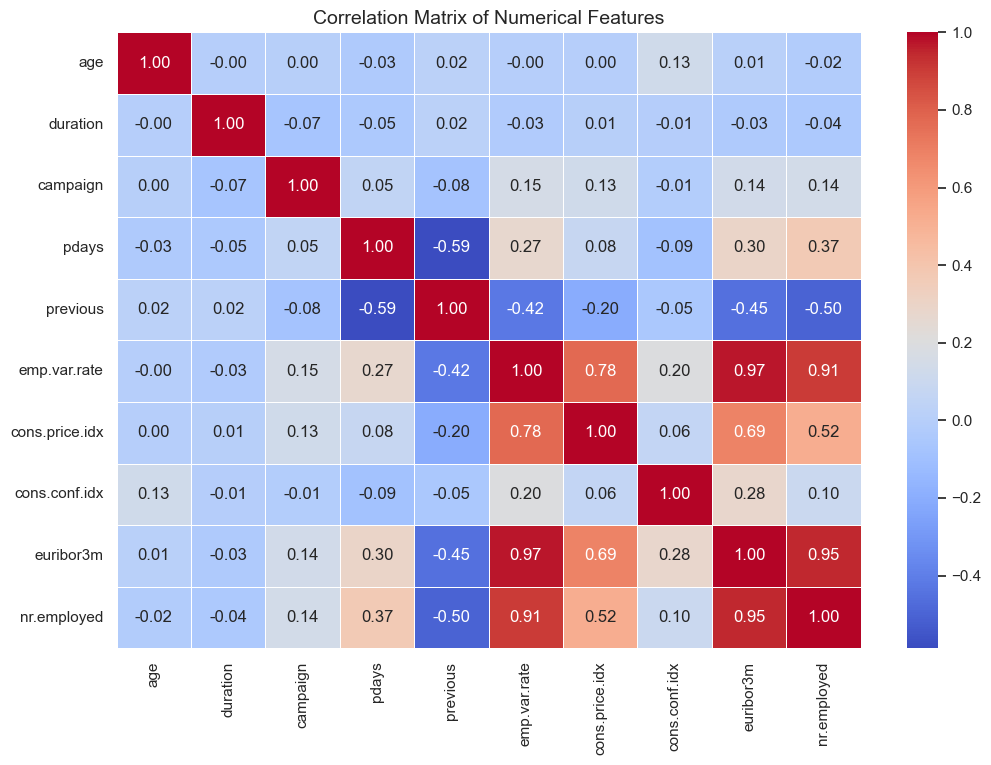

In [36]:

# Correlation matrix for numerical features
# 1. Isolate the numerical columns
numerical_df = df.select_dtypes(include=['number'])

# 2. Calculate the correlation values (-1 to 1)
corr_matrix = numerical_df.corr()

# 3. Create a Heatmap to visualize the matrix
plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Matrix of Numerical Features', fontsize=14)
plt.show()


In [37]:
#Predicting whether a client will subscribe to a term deposit.
#Encoding Categorical Features
# Convert categorical features into numerical dummy variables
df_model = pd.get_dummies(df, columns=['job', 'marital', 'education', 'default', 
                                        'housing', 'loan', 'contact', 'month', 
                                        'day_of_week', 'poutcome'], drop_first=True)

# Convert the target variable 'y' to binary: yes=1, no=0
df_model['y'] = df_model['y'].map({'yes': 1, 'no': 0})

In [38]:
from sklearn.model_selection import train_test_split
# Ensure categorical columns are encoded and the target variable is defined
df_model = pd.get_dummies(df, drop_first=True)
X = df_model.drop(['y_yes'], axis=1) # Features (all columns except the target)
y = df_model['y_yes']              # Target (the 'yes' subscription outcome)

# 2. Define X_train and X_test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [39]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)# Use pd.get_dummies to turn intervals into numerical columns the scaler can read
X_train = pd.get_dummies(X_train)
X_test = pd.get_dummies(X_test)

# Ensure both training and test sets have the exact same columns after encoding
X_train, X_test = X_train.align(X_test, join='left', axis=1, fill_value=0)

# 2. Scale the data (now that it is all numeric)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [40]:
from sklearn.linear_model import LogisticRegression

# 1. Preprocess: Convert categories to numbers and target 'y' to binary (1/0)
df_model = pd.get_dummies(df, drop_first=True)
X = df_model.drop(['y_yes'], axis=1) # Features
y = df_model['y_yes']              # Target

# 2. Split: Create training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Scale: Normalize numerical ranges for the model
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Model Performance Report:
              precision    recall  f1-score   support

       False       0.93      0.98      0.95      7290
        True       0.70      0.45      0.54       947

    accuracy                           0.91      8237
   macro avg       0.81      0.71      0.75      8237
weighted avg       0.90      0.91      0.91      8237



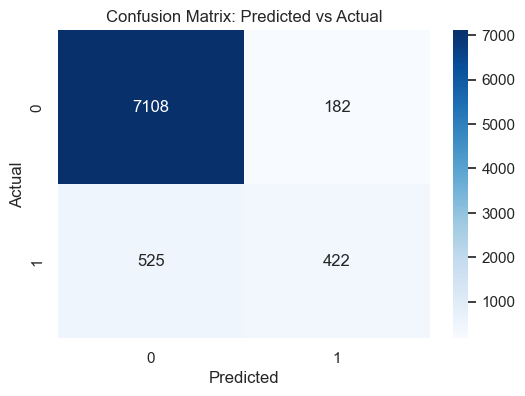

In [44]:
#Building and Evaluating the Model
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix

# Initialize and train the model
model = LogisticRegression(max_iter=1000)
model.fit(X_train_scaled, y_train)

# Make predictions
y_pred = model.predict(X_test_scaled)

# Evaluate the model
print("Model Performance Report:")
print(classification_report(y_test, y_pred))

# Visualize accuracy with a Confusion Matrix
plt.figure(figsize=(6,4))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix: Predicted vs Actual')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

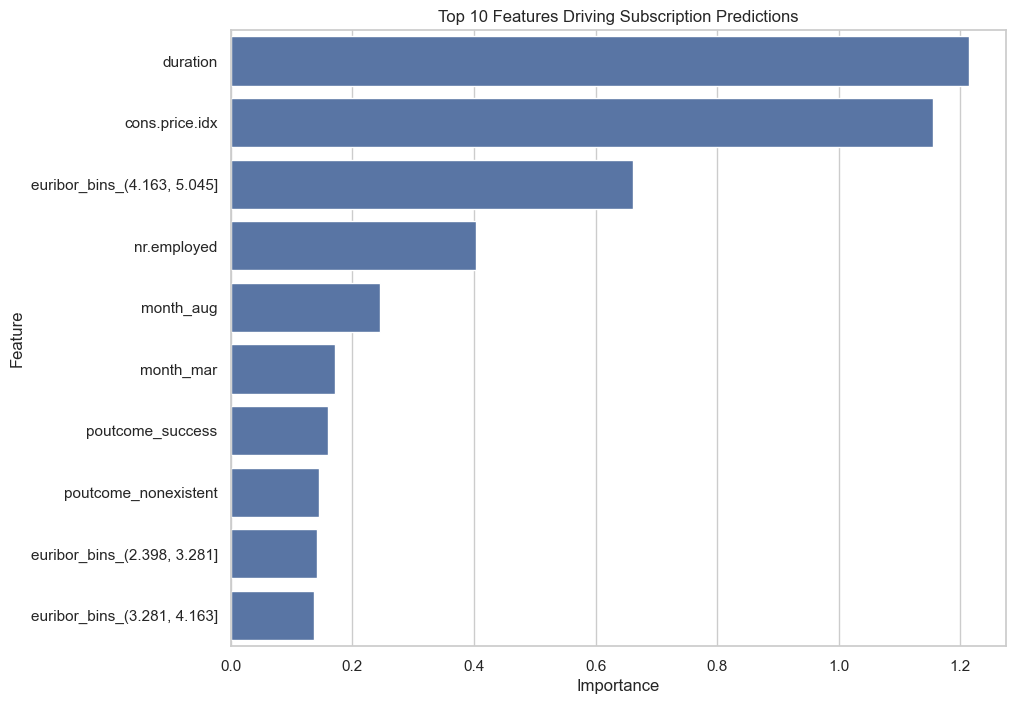

In [43]:
#Business_Insight
importance = model.coef_[0]
feature_names = X.columns
feature_importance = pd.DataFrame({'Feature': feature_names, 'Importance': importance})
feature_importance = feature_importance.sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 8))
sns.barplot(x='Importance', y='Feature', data=feature_importance.head(10))
plt.title('Top 10 Features Driving Subscription Predictions')
plt.show()

# Conclusion
In this project, I tried to understand what really influences a customer’s decision to subscribe to a term deposit. I used a Logistic Regression model, which gave an overall accuracy of about 91% on the test data.
## Key Takeaways:

One important thing I noticed is that even though the model has high accuracy, the recall for predicting actual subscribers is only 0.45. This means the model is quite conservative—it correctly predicts “yes” cases about 70% of the time, but it still misses more than half of the people who would have actually subscribed.

The most significant factor turned out to be call duration. Customers who stayed longer on calls were much more likely to subscribe, which shows that better engagement during conversations really matters.

I also found that external economic factors like the Consumer Price Index and Euribor rates affect customer decisions. People seem more willing to invest when the economic conditions feel stable.

Another interesting insight was about timing. Campaigns conducted in March and August performed better compared to other months, suggesting that timing plays a role in customer response.

## Business Recommendations:

Based on these findings, I think the bank should focus more on the quality of customer interactions instead of just increasing the number of calls. Training employees to have more meaningful conversations could improve results.

It would also be useful to focus marketing efforts during the months that historically perform better, like March and August.

Lastly, the bank should keep an eye on economic conditions and adjust their marketing strategies accordingly, so they can target customers when they are more likely to invest.

Overall, this approach can help shift from mass marketing to a more targeted strategy, focusing on customers who are more likely to convert.
